# Customer Churn Analisys

## Essencial Libraries

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## Loading Data

In [26]:
df = pd.read_csv(
    "../data/Telco_customer_churn.csv",
    sep=";"
)

## Initial Exploratory Analysis

In [ ]:
df.head()

In [ ]:
df.shape

In [ ]:
df.info()

In [ ]:
df.isnull().sum().sort_values(ascending=False)

## Data Cleaning

In [31]:
df["Total Charges"] = pd.to_numeric(
    df["Total Charges"].str.replace(",", ".", regex=False),
    errors="coerce"
)
df["Monthly Charges"] = pd.to_numeric(
    df["Monthly Charges"].str.replace(",", ".", regex=False),
    errors="coerce"
)

In [32]:
df = df.dropna(subset=["Total Charges"])

## Churn Rate Analysis

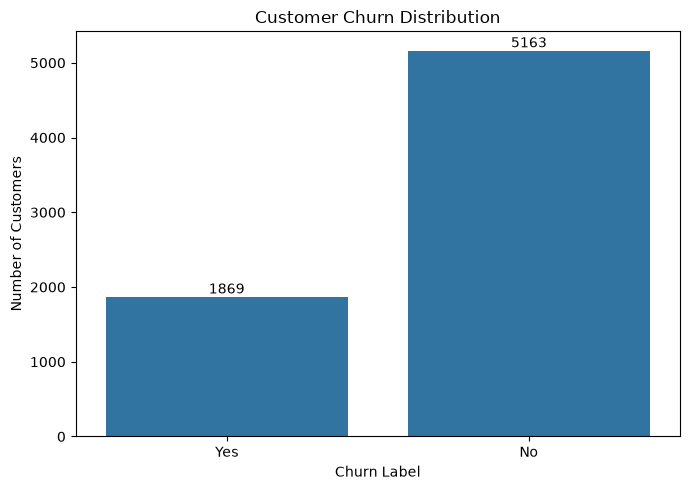

Churn Label
No     73.42%
Yes    26.58%
Name: proportion, dtype: str


In [42]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="Churn Label"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Label")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()
churn_percentage = (
    df["Churn Label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(churn_percentage.astype(str) + "%")

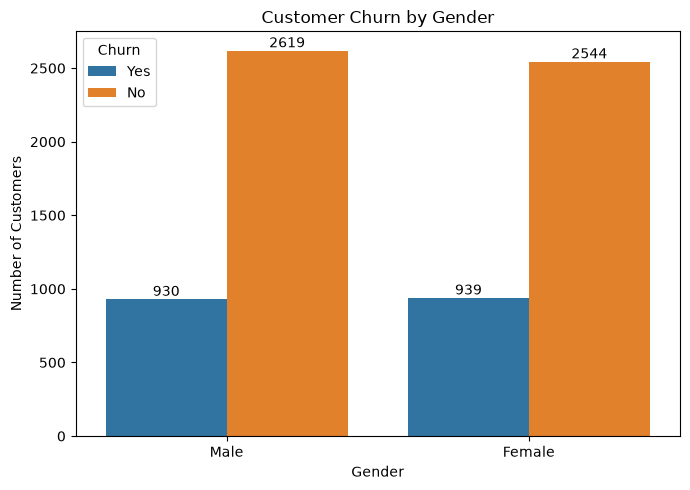

Churn Label      No     Yes
Gender                     
Female       73.04%  26.96%
Male          73.8%   26.2%


In [44]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="Gender",
    hue="Churn Label"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.tight_layout()
plt.show()

churn_by_gender = (
pd.crosstab(
    df["Gender"],
    df["Churn Label"],
    normalize="index"
) * 100).round(2)
print(churn_by_gender.astype(str) + "%")

### Analysis

There is little difference in churn behavior between male and female customers.

suggesting that gender does not appear to be strongly associated with customer churn in this dataset.

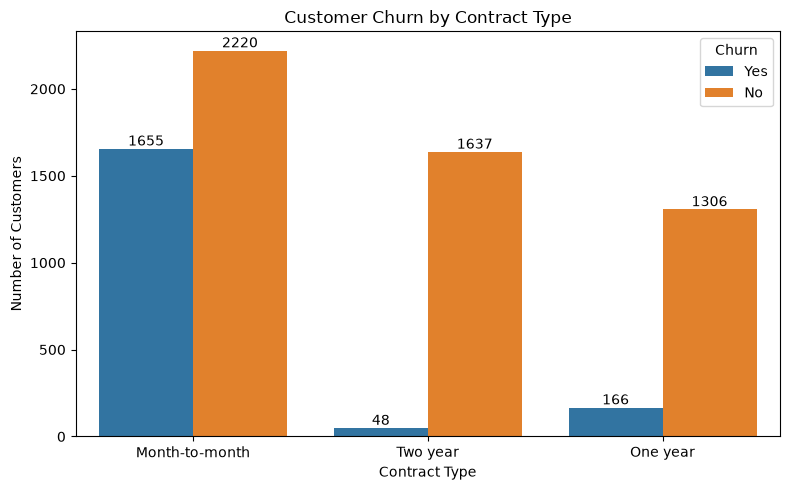

Churn Value          0       1
Contract                      
Month-to-month  57.29%  42.71%
One year        88.72%  11.28%
Two year        97.15%   2.85%


In [45]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Contract",
    hue="Churn Label")

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.tight_layout()
plt.show()

churn_by_contract = (
pd.crosstab(
    df["Contract"],
    df["Churn Value"],
    normalize="index"
) * 100).round(2)
print(churn_by_contract.astype(str) + "%")

### Analysis

Contract type shows a strong relationship with customer churn.

Customers with month-to-month contracts have a substantially higher churn rate, with approximately 42.7% of these customers churning. In comparison, the churn rate is approximately 11.3% for one-year contracts and only 2.8% for two-year contracts.

This suggests that customers with shorter-term contracts are considerably more likely to churn, while customers with longer-term contracts tend to have much lower churn rates.

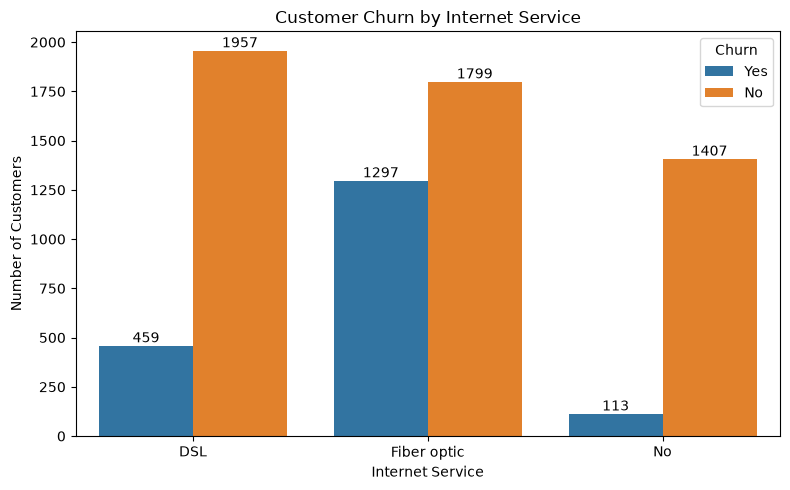

Churn Label           No     Yes
Internet Service                
DSL                81.0%   19.0%
Fiber optic       58.11%  41.89%
No                92.57%   7.43%


In [46]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Internet Service",
    hue="Churn Label"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.tight_layout()
plt.show()

internet_service_churn =(
pd.crosstab(
    df["Internet Service"],
    df["Churn Label"],
    normalize="index"
) * 100).round(2)
print(internet_service_churn.astype(str) + "%")

### Analysis

Churn behavior varies considerably across Internet Service types.

Customers with Fiber Optic service have a substantially higher churn rate than customers with DSL or no Internet service. Approximately 41.9% of Fiber Optic customers churned, compared with 19.0% of DSL customers and 7.4% of customers without Internet service.

This suggests that Internet Service may be an important feature for predicting customer churn, particularly for customers using Fiber Optic service.

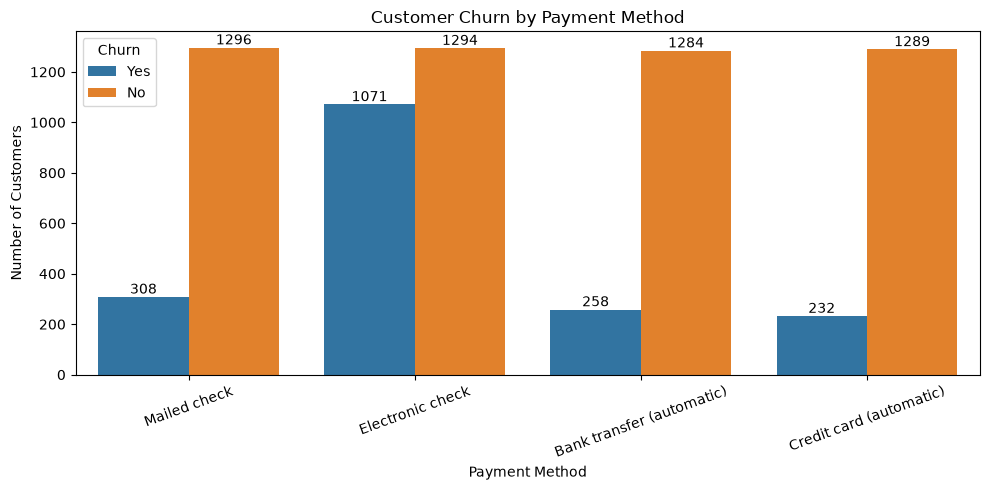

Churn Label                    No     Yes
Payment Method                           
Bank transfer (automatic)  83.27%  16.73%
Credit card (automatic)    84.75%  15.25%
Electronic check           54.71%  45.29%
Mailed check                80.8%   19.2%


In [49]:
plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=df,
    x="Payment Method",
    hue="Churn Label"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.legend(title="Churn")

plt.tight_layout()
plt.show()

payment_table = (
    pd.crosstab(
        df["Payment Method"],
        df["Churn Label"],
        normalize="index"
    ) * 100
).round(2)

print(payment_table.astype(str) + "%")

### Analysis

The payment method shows a noticeable difference in churn behavior.

Customers using Electronic Check have a substantially higher number of churned customers compared with the other payment methods. In contrast, Mailed Check, Bank Transfer (automatic), and Credit Card (automatic) show considerably fewer churned customers.

This suggests that Electronic Check may be an important feature for predicting customer churn. However, the chart shows absolute customer counts, so the differences should also be evaluated using churn rates within each payment method.

,count,mean,std,min,25%,50%,75%,max
Churn Label,,,,,,,,
No,5163.0,61.31,31.09,18.25,25.10,64.45,88.48,118.75
Yes,1869.0,74.44,24.67,18.85,56.15,79.65,94.20,118.35


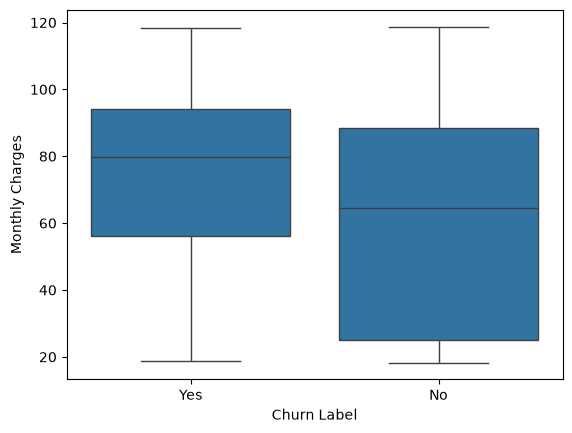

In [38]:
sns.boxplot(
    data=df,
    x="Churn Label",
    y="Monthly Charges"
)
df.groupby("Churn Label")["Monthly Charges"].describe().round(2)

### Analysis

Customers who churned are more concentrated at lower Total Charges values, while customers who did not churn are more widely distributed across higher values.

This may be related to customer tenure, since customers who leave the company earlier have less time to accumulate Total Charges. Therefore, this variable should be interpreted together with tenure and other customer characteristics.

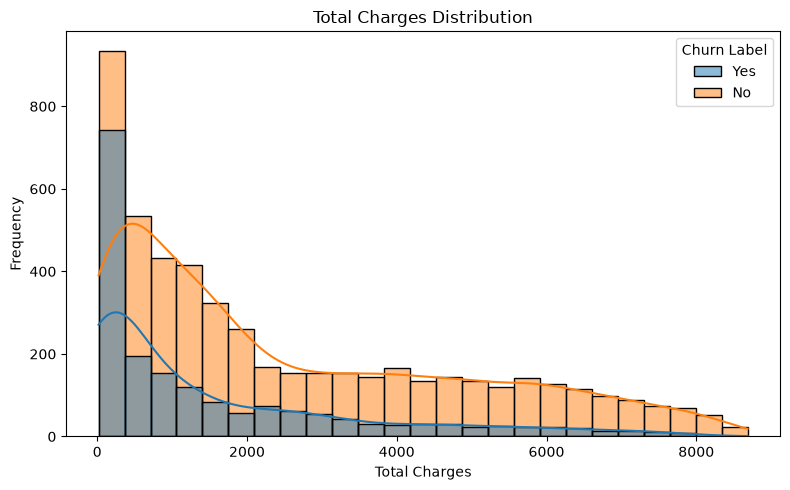

,count,mean,std,min,25%,50%,75%,max
Churn Label,,,,,,,,
No,5163.0,2555.34,2329.46,18.80,577.83,1683.60,4264.12,8672.45
Yes,1869.0,1531.80,1890.82,18.85,134.50,703.55,2331.30,8684.80


In [39]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Total Charges",
    hue="Churn Label",
    kde=True
)

plt.title("Total Charges Distribution")
plt.xlabel("Total Charges")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()
df.groupby("Churn Label")["Total Charges"].describe().round(2)

### Analysis

Customers who churned tend to have higher Monthly Charges than customers who did not churn.

The median Monthly Charges is approximately 80 for churned customers, compared with around 65 for customers who stayed. This suggests that higher monthly charges may be associated with a greater likelihood of churn.

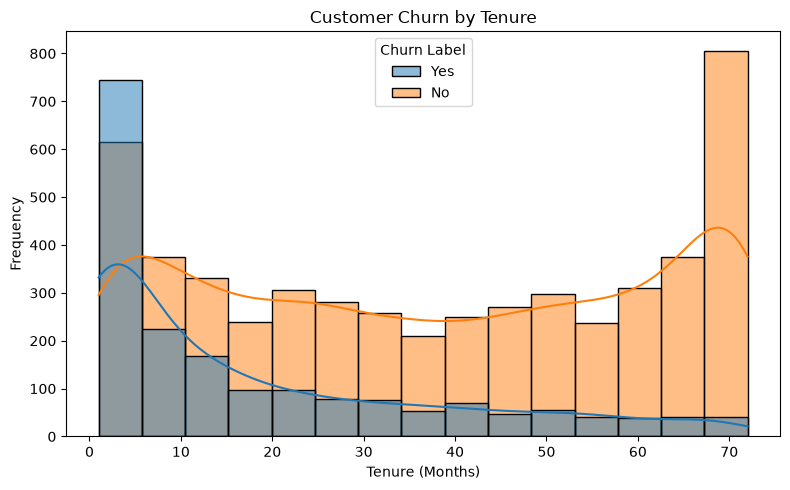

,count,mean,std,min,25%,50%,75%,max
Churn Label,,,,,,,,
No,5163.0,37.65,24.08,1.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.98,19.53,1.0,2.0,10.0,29.0,72.0


In [40]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Tenure Months",
    hue="Churn Label",
    kde=True
)

plt.title("Customer Churn by Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()
df.groupby("Churn Label")["Tenure Months"].describe().round(2)